In [40]:
# ============================================================
# CELL 1: Install all required packages
# ============================================================
import subprocess, sys

packages = [
    "transformers>=4.45.0",
    "peft>=0.12.0",
    "bitsandbytes>=0.43.0",
    "trl>=0.11.0",
    "accelerate>=0.34.0",
    "datasets>=2.20.0",
    "qwen-vl-utils",
    "torchvision",
    "Pillow",
    "evaluate",
    "rouge_score",
    "gradio",
    "matplotlib",
    "seaborn",
    "pandas",
    "numpy",
    "tqdm",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [41]:
# ============================================================
# CELL 2: Import all libraries
# ============================================================
import os
import gc
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display, Markdown, clear_output

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import transformers
from transformers import (
    AutoProcessor,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from transformers import Qwen2VLForConditionalGeneration

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    prepare_model_for_kbit_training,
    PeftModel,
)

from trl import SFTTrainer, SFTConfig

from datasets import load_dataset, Dataset as HFDataset

try:
    from qwen_vl_utils import process_vision_info
    print("✅ qwen_vl_utils loaded")
except ImportError:
    print("⚠️  qwen_vl_utils not found – will handle vision processing manually")

import evaluate

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"\n📦 Transformers version : {transformers.__version__}")
print(f"🔥 PyTorch version      : {torch.__version__}")
print(f"🖥️  CUDA available       : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"   GPU {i}: {props.name} | VRAM: {props.total_memory / 1e9:.1f} GB")

✅ qwen_vl_utils loaded

📦 Transformers version : 5.0.0
🔥 PyTorch version      : 2.10.0+cu128
🖥️  CUDA available       : True
   GPU 0: Tesla T4 | VRAM: 15.6 GB
   GPU 1: Tesla T4 | VRAM: 15.6 GB


In [42]:
# ============================================================
# CELL 3: Global Configuration
# ============================================================
class CFG:
    # ── Model ──────────────────────────────────────────────
    MODEL_ID          = "Qwen/Qwen2-VL-2B-Instruct"
    OUTPUT_DIR        = "/kaggle/working/qwen2vl_qlora"
    FINAL_MODEL_DIR   = "/kaggle/working/qwen2vl_final"

    # ── Dataset ────────────────────────────────────────────
    DATASET_NAME      = "zphilip/nougat-training-dataset-example"
    MAX_SAMPLES       = 500        # Set None to use full dataset
    TRAIN_RATIO       = 0.80
    VAL_RATIO         = 0.20

    # ── QLoRA / Quantization ───────────────────────────────
    LOAD_IN_4BIT      = True
    BNB_4BIT_QUANT    = "nf4"      # NormalFloat4
    COMPUTE_DTYPE     = torch.float16
    DOUBLE_QUANT      = True

    # ── LoRA ───────────────────────────────────────────────
    LORA_R            = 16         # rank
    LORA_ALPHA        = 32         # scaling = alpha / r
    LORA_DROPOUT      = 0.05
    LORA_TARGETS      = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ]

    # ── Training ───────────────────────────────────────────
    NUM_EPOCHS        = 3          # Set 2 or 5 for bonus comparison
    BATCH_SIZE        = 1
    GRAD_ACCUM        = 8          # Effective batch = 1*8 = 8
    LEARNING_RATE     = 1e-4
    WARMUP_RATIO      = 0.05
    LR_SCHEDULER      = "cosine"
    MAX_SEQ_LEN       = 1024
    WEIGHT_DECAY      = 0.01

    # ── Image ──────────────────────────────────────────────
    IMAGE_SIZE        = 512        # px (512–768 recommended)

    # ── Generation ─────────────────────────────────────────
    MAX_NEW_TOKENS    = 1024
    TEMPERATURE       = 0.1
    DO_SAMPLE         = False

    # ── Instruction Prompt ─────────────────────────────────
    INSTRUCTION = (
        "You are an expert document parser. "
        "Convert the document image into well-structured Markdown. "
        "Preserve all headings, bullet points, numbered lists, "
        "tables, mathematical equations, and code blocks. "
        "Output ONLY valid Markdown without any extra commentary."
    )

os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
os.makedirs(CFG.FINAL_MODEL_DIR, exist_ok=True)

print("⚙️  Configuration loaded:")
for k, v in vars(CFG).items():
    if not k.startswith("_"):
        print(f"   {k:20s} = {v}")

⚙️  Configuration loaded:
   MODEL_ID             = Qwen/Qwen2-VL-2B-Instruct
   OUTPUT_DIR           = /kaggle/working/qwen2vl_qlora
   FINAL_MODEL_DIR      = /kaggle/working/qwen2vl_final
   DATASET_NAME         = zphilip/nougat-training-dataset-example
   MAX_SAMPLES          = 500
   TRAIN_RATIO          = 0.8
   VAL_RATIO            = 0.2
   LOAD_IN_4BIT         = True
   BNB_4BIT_QUANT       = nf4
   COMPUTE_DTYPE        = torch.float16
   DOUBLE_QUANT         = True
   LORA_R               = 16
   LORA_ALPHA           = 32
   LORA_DROPOUT         = 0.05
   LORA_TARGETS         = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
   NUM_EPOCHS           = 3
   BATCH_SIZE           = 1
   GRAD_ACCUM           = 8
   LEARNING_RATE        = 0.0001
   WARMUP_RATIO         = 0.05
   LR_SCHEDULER         = cosine
   MAX_SEQ_LEN          = 1024
   WEIGHT_DECAY         = 0.01
   IMAGE_SIZE           = 512
   MAX_NEW_TOKENS       = 1024
   TEMPERATURE          =

In [44]:
# ============================================================
# CELL 4: Load Local Nougat Dataset (Robust)
# ============================================================

import os
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import random
from tqdm.auto import tqdm
from datasets import Dataset as HFDataset

print("📥 Loading local Nougat dataset...")

# === UPDATE THIS PATH IF NEEDED ===
DATA_ROOT = "/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508"

pairs = []
skipped = 0

for arxiv_dir in tqdm(list(Path(DATA_ROOT).iterdir()), desc="Scanning directories"):
    if not arxiv_dir.is_dir():
        continue
    for png_file in arxiv_dir.glob("*.png"):
        mmd_file = png_file.with_suffix(".mmd")
        if mmd_file.exists():
            # Quick validity check
            try:
                with open(png_file, "rb") as f:
                    header = f.read(8)
                if not header.startswith(b'\x89PNG\r\n\x1a\n'):
                    skipped += 1
                    continue
            except:
                skipped += 1
                continue

            pairs.append({
                "image_path": str(png_file),
                "markdown_path": str(mmd_file),
                "arxiv_id": arxiv_dir.name,
                "page": png_file.stem
            })

print(f"✅ Found {len(pairs)} valid document page pairs")
print(f"   Skipped corrupted files: {skipped}")

# Shuffle
random.shuffle(pairs)

# Limit if configured
if CFG.MAX_SAMPLES and CFG.MAX_SAMPLES < len(pairs):
    pairs = pairs[:CFG.MAX_SAMPLES]
    print(f"   Limited to first {CFG.MAX_SAMPLES} samples as per CFG")

# ===================================================================
def load_pair(item):
    """Safe image + markdown loader"""
    try:
        img = Image.open(item["image_path"])
        if img.mode != 'RGB':
            img = img.convert('RGB')
        with open(item["markdown_path"], "r", encoding="utf-8") as f:
            markdown = f.read().strip()
        return {
            "image": img,
            "markdown": markdown,
            "arxiv_id": item["arxiv_id"],
            "page": item["page"]
        }
    except (UnidentifiedImageError, OSError, IOError) as e:
        print(f"⚠️  Skipping corrupted image: {item['image_path']} | Error: {e}")
        return None

# Build dataset with error skipping
raw_data = []
for p in tqdm(pairs, desc="Loading images and markdown"):
    result = load_pair(p)
    if result is not None:
        raw_data.append(result)

dataset = HFDataset.from_list(raw_data)

print(f"\n🎉 Final dataset: {len(dataset)} samples")
print(f"   Features: {list(dataset[0].keys()) if len(dataset) > 0 else 'None'}")

📥 Loading local Nougat dataset...


Scanning directories:   0%|          | 0/2230 [00:00<?, ?it/s]

✅ Found 14207 valid document page pairs
   Skipped corrupted files: 29
   Limited to first 500 samples as per CFG


Loading images and markdown:   0%|          | 0/500 [00:00<?, ?it/s]


🎉 Final dataset: 500 samples
   Features: ['image', 'markdown', 'arxiv_id', 'page']


In [ ]:
# ============================================================
# CELL 5: Inspect Dataset Structure
# ============================================================

print("🔍 Dataset Feature Schema:")
print(dataset.features)

IMAGE_COL = "image"
TEXT_COL  = "markdown"

print(f"📸 Image column  : '{IMAGE_COL}'")
print(f"📝 Text column   : '{TEXT_COL}'")

# Show one sample
sample = dataset[0]
print(f"\nSample arXiv: {sample['arxiv_id']}, Page: {sample['page']}")

🔍 Dataset Feature Schema:
{'image': Image(mode=None, decode=True), 'markdown': Value('string'), 'arxiv_id': Value('string'), 'page': Value('string')}
📸 Image column  : 'image'
📝 Text column   : 'markdown'

Sample arXiv: hep-th0508041, Page: 06


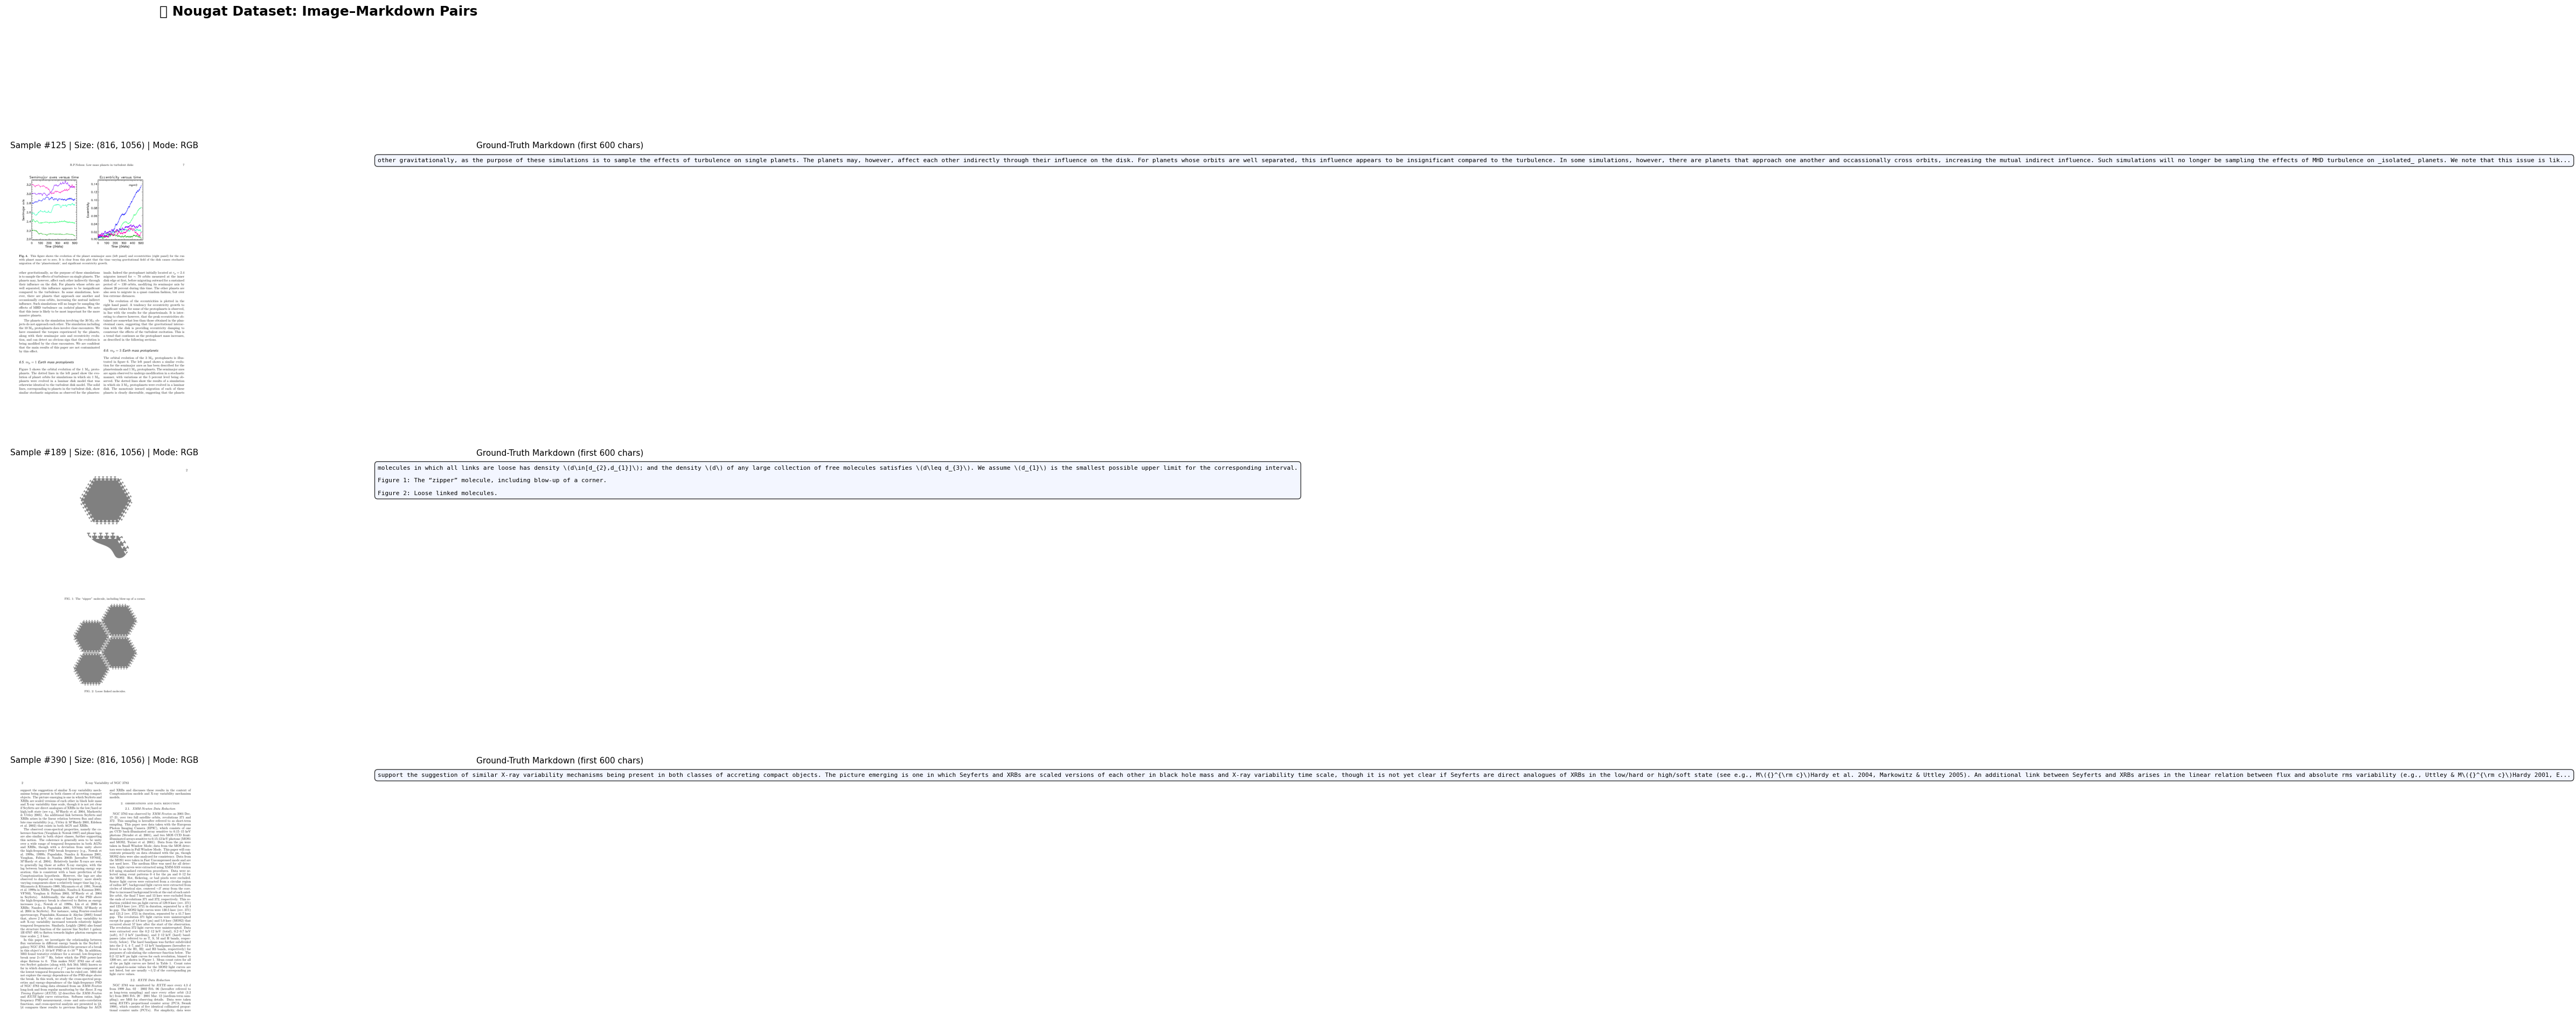

✅ Saved: /kaggle/working/dataset_exploration.png


In [46]:
# ============================================================
# CELL 6: Visualize Sample Image-Markdown Pairs
# ============================================================
def show_sample_pairs(dataset, image_col, text_col, n=3):
    """Display n document images alongside their markdown targets."""
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    
    fig = plt.figure(figsize=(20, 7 * n))
    fig.suptitle("📄 Nougat Dataset: Image–Markdown Pairs",
                 fontsize=18, fontweight='bold', y=1.01)
    
    for row_idx, idx in enumerate(indices):
        sample   = dataset[idx]
        img      = sample[image_col]
        md_text  = sample[text_col] if text_col and text_col in sample else "[No text column found]"
        
        # Ensure PIL Image
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        
        # Left panel: document image
        ax_img = fig.add_subplot(n, 2, row_idx * 2 + 1)
        ax_img.imshow(img, cmap='gray' if img.mode == 'L' else None)
        ax_img.set_title(f"Sample #{idx} | Size: {img.size} | Mode: {img.mode}",
                         fontsize=11)
        ax_img.axis('off')
        
        # Right panel: markdown text
        ax_txt = fig.add_subplot(n, 2, row_idx * 2 + 2)
        ax_txt.axis('off')
        preview = md_text[:600] + ("..." if len(md_text) > 600 else "")
        ax_txt.text(
            0.02, 0.98, preview,
            transform=ax_txt.transAxes,
            fontsize=8, va='top', ha='left',
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f4ff', alpha=0.8)
        )
        ax_txt.set_title(f"Ground-Truth Markdown (first 600 chars)", fontsize=11)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/dataset_exploration.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("✅ Saved: /kaggle/working/dataset_exploration.png")

show_sample_pairs(dataset, IMAGE_COL, TEXT_COL, n=3)

📈 Computing dataset statistics...



Analyzing samples:   0%|          | 0/200 [00:00<?, ?it/s]

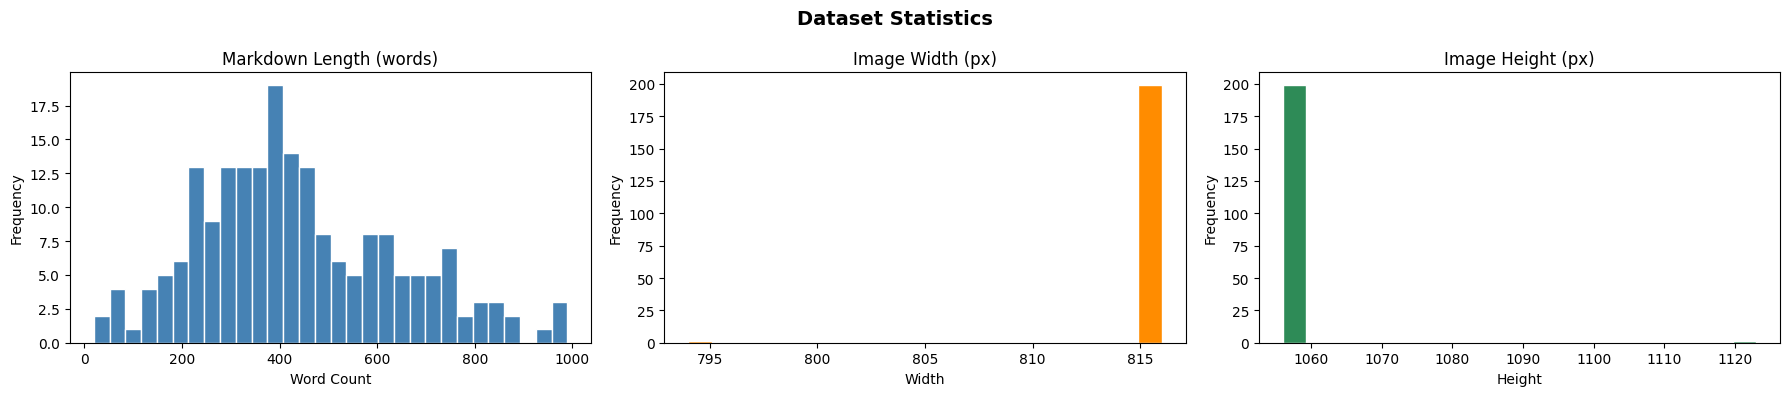


Metric                              Value
------------------------------------------
Total samples                         500
Avg markdown words                    438
Max markdown words                    990
Avg image width (px)                  816
Avg image height (px)                1056


In [47]:
# ============================================================
# CELL 7: Dataset Statistics
# ============================================================
print("📈 Computing dataset statistics...\n")

# Sample up to 200 items for stats
stat_limit = min(200, len(dataset))
md_lengths, img_widths, img_heights = [], [], []

for i in tqdm(range(stat_limit), desc="Analyzing samples"):
    s  = dataset[i]
    md = s.get(TEXT_COL, "")
    im = s.get(IMAGE_COL)
    md_lengths.append(len(md.split()) if md else 0)
    if im is not None:
        if not isinstance(im, Image.Image):
            im = Image.fromarray(im)
        img_widths.append(im.size[0])
        img_heights.append(im.size[1])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Dataset Statistics", fontsize=14, fontweight='bold')

axes[0].hist(md_lengths, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Markdown Length (words)')
axes[0].set_xlabel('Word Count'); axes[0].set_ylabel('Frequency')

axes[1].hist(img_widths, bins=20, color='darkorange', edgecolor='white')
axes[1].set_title('Image Width (px)')
axes[1].set_xlabel('Width'); axes[1].set_ylabel('Frequency')

axes[2].hist(img_heights, bins=20, color='seagreen', edgecolor='white')
axes[2].set_title('Image Height (px)')
axes[2].set_xlabel('Height'); axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('/kaggle/working/dataset_stats.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n{'Metric':30s} {'Value':>10}")
print("-" * 42)
print(f"{'Total samples':30s} {len(dataset):>10,}")
print(f"{'Avg markdown words':30s} {np.mean(md_lengths):>10.0f}")
print(f"{'Max markdown words':30s} {np.max(md_lengths):>10,}")
print(f"{'Avg image width (px)':30s} {np.mean(img_widths):>10.0f}")
print(f"{'Avg image height (px)':30s} {np.mean(img_heights):>10.0f}")

In [48]:
# ============================================================
# CELL 8: Load Qwen2-VL Processor
# ============================================================
print(f"⬇️  Loading processor from: {CFG.MODEL_ID}")

processor = AutoProcessor.from_pretrained(
    CFG.MODEL_ID,
    trust_remote_code=True,
    min_pixels=256 * 28 * 28,
    max_pixels=CFG.IMAGE_SIZE * CFG.IMAGE_SIZE,
)

print(f"✅ Processor loaded")
print(f"   Type                : {type(processor).__name__}")
print(f"   Tokenizer vocab size: {processor.tokenizer.vocab_size:,}")

⬇️  Loading processor from: Qwen/Qwen2-VL-2B-Instruct
✅ Processor loaded
   Type                : Qwen2VLProcessor
   Tokenizer vocab size: 151,643


In [49]:
# ============================================================
# CELL 9: ChatML Formatting Utilities
# ============================================================

def preprocess_image(img, target_size=CFG.IMAGE_SIZE):
    """Resize & normalize a PIL image for model input."""
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    # Resize keeping aspect ratio, pad to square
    img.thumbnail((target_size, target_size), Image.LANCZOS)
    padded = Image.new('RGB', (target_size, target_size), (255, 255, 255))
    offset = ((target_size - img.size[0]) // 2, (target_size - img.size[1]) // 2)
    padded.paste(img, offset)
    return padded


def build_chatml_message(image: Image.Image, instruction: str, markdown: str = None):
    """
    Build a ChatML-format conversation dict.
    If markdown is provided → training sample (with assistant turn).
    If markdown is None     → inference sample (user turn only).
    """
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text": instruction},
            ],
        }
    ]
    if markdown is not None:
        messages.append(
            {"role": "assistant", "content": markdown}
        )
    return messages


def collate_fn(examples, processor, max_length=CFG.MAX_SEQ_LEN):
    """
    Custom collate function for SFTTrainer.
    Applies chat template, processes images + text together.
    """
    texts, images_list = [], []

    for ex in examples:
        messages = ex["messages"]
        # Apply chat template (adds special tokens / im_start, im_end)
        text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
        texts.append(text)
        # Extract PIL images from message list
        imgs = []
        for msg in messages:
            for part in (msg.get("content") if isinstance(msg.get("content"), list) else []):
                if isinstance(part, dict) and part.get("type") == "image":
                    imgs.append(part["image"])
        images_list.append(imgs if imgs else None)

    batch = processor(
        text=texts,
        images=[i for i in images_list if i],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_length,
    )

    # Labels = input_ids; mask padding with -100
    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100

    # Mask the user-turn tokens so we only compute loss on assistant output
    # Find the assistant token boundary
    assistant_token = processor.tokenizer.encode("<|im_start|>assistant", add_special_tokens=False)
    for i in range(labels.shape[0]):
        ids = labels[i].tolist()
        # Mask everything before (and including) the assistant start token
        for j in range(len(ids) - len(assistant_token)):
            if ids[j:j+len(assistant_token)] == assistant_token:
                labels[i, :j + len(assistant_token)] = -100
                break

    batch["labels"] = labels
    return batch


print("✅ ChatML utilities defined")

# Show a formatted example
sample       = dataset[0]
sample_img   = preprocess_image(sample[IMAGE_COL])
sample_md    = sample.get(TEXT_COL, "")
sample_msgs  = build_chatml_message(sample_img, CFG.INSTRUCTION, sample_md)
sample_text  = processor.apply_chat_template(sample_msgs, tokenize=False, add_generation_prompt=False)

print("\n📋 ChatML Format Preview:")
print("─" * 60)
print(sample_text[:800])
print("─" * 60)

✅ ChatML utilities defined

📋 ChatML Format Preview:
────────────────────────────────────────────────────────────
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>You are an expert document parser. Convert the document image into well-structured Markdown. Preserve all headings, bullet points, numbered lists, tables, mathematical equations, and code blocks. Output ONLY valid Markdown without any extra commentary.<|im_end|>
<|im_start|>assistant
defined Hamiltonian formalism. In Einstein-Maxwell theory, a point in the phase space is specified by the initial data \((s_{ab},\pi^{ab},\tilde{A}_{a},E^{a})\) on a spacelike surface \(\Sigma\), where \(\tilde{A}_{a}=s_{a}^{c}A_{c}\) is the projection onto \(\Sigma\) of the spacetime gauge potential \(A_{a}\). \(\pi^{ab}\) is the momentum conjugate to \(s_{ab}\), and is related to the extrinsi
────────────────────────────────────────────────────────────


✅ Datasets prepared:
   Total samples used : 500
   Training samples   : 400 (80%)
   Validation samples : 100   (20%)


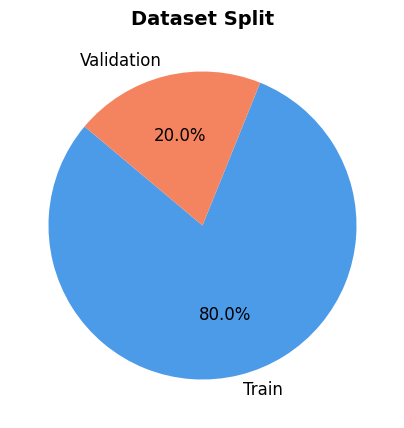

In [50]:
# ============================================================
# CELL 10: Subset & Split
# ============================================================

class NougatChatDataset(Dataset):
    """PyTorch Dataset that wraps Nougat HF dataset into ChatML format."""

    def __init__(self, hf_dataset, image_col, text_col, instruction,
                 image_size=CFG.IMAGE_SIZE, indices=None):
        self.hf_dataset  = hf_dataset
        self.image_col   = image_col
        self.text_col    = text_col
        self.instruction = instruction
        self.image_size  = image_size
        self.indices     = indices if indices is not None else list(range(len(hf_dataset)))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        sample   = self.hf_dataset[real_idx]

        img = preprocess_image(sample[self.image_col], self.image_size)
        md  = sample.get(self.text_col, "")

        messages = build_chatml_message(img, self.instruction, md)
        return {"messages": messages, "raw_image": img, "raw_markdown": md}


# ── Determine subset size ──
total   = len(dataset)
n_use   = CFG.MAX_SAMPLES if CFG.MAX_SAMPLES and CFG.MAX_SAMPLES < total else total

all_indices = list(range(total))
random.shuffle(all_indices)
selected    = all_indices[:n_use]

# ── Train / Val split ──
n_train = int(len(selected) * CFG.TRAIN_RATIO)
n_val   = len(selected) - n_train

train_indices = selected[:n_train]
val_indices   = selected[n_train:]

train_dataset = NougatChatDataset(dataset, IMAGE_COL, TEXT_COL,
                                   CFG.INSTRUCTION, indices=train_indices)
val_dataset   = NougatChatDataset(dataset, IMAGE_COL, TEXT_COL,
                                   CFG.INSTRUCTION, indices=val_indices)

print("✅ Datasets prepared:")
print(f"   Total samples used : {n_use}")
print(f"   Training samples   : {len(train_dataset)} ({CFG.TRAIN_RATIO*100:.0f}%)")
print(f"   Validation samples : {len(val_dataset)}   ({CFG.VAL_RATIO*100:.0f}%)")

# Visualise split
labels_pie = ['Train', 'Validation']
sizes_pie  = [len(train_dataset), len(val_dataset)]
colors_pie = ['#4C9BE8', '#F4845F']

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(sizes_pie, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%',
       startangle=140, textprops={'fontsize': 12})
ax.set_title('Dataset Split', fontsize=14, fontweight='bold')
plt.savefig('/kaggle/working/split_pie.png', dpi=120, bbox_inches='tight')
plt.show()

In [51]:
# ============================================================
# CELL 11: Load Base Model with 4-bit Quantization
# ============================================================

# Clear VRAM before loading
gc.collect()
torch.cuda.empty_cache()

print("⚙️  Configuring 4-bit quantization (BitsAndBytes)...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit            = CFG.LOAD_IN_4BIT,
    bnb_4bit_quant_type     = CFG.BNB_4BIT_QUANT,    # "nf4"
    bnb_4bit_compute_dtype  = CFG.COMPUTE_DTYPE,
    bnb_4bit_use_double_quant = CFG.DOUBLE_QUANT,
)

print(f"\n⬇️  Loading model: {CFG.MODEL_ID}")
print("   This may take 2-5 minutes on first run...")

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    CFG.MODEL_ID,
    quantization_config = bnb_config,
    device_map          = "auto",        # auto-splits across 2×T4
    torch_dtype         = CFG.COMPUTE_DTYPE,
    trust_remote_code   = True,
)

base_model.config.use_cache = False      # Needed for gradient checkpointing

print(f"\n✅ Model loaded in 4-bit!")
print(f"   Total parameters : {sum(p.numel() for p in base_model.parameters()):,}")

# Show memory usage
for i in range(torch.cuda.device_count()):
    used  = torch.cuda.memory_allocated(i) / 1e9
    total = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f"   GPU {i} memory: {used:.2f} GB / {total:.2f} GB")

⚙️  Configuring 4-bit quantization (BitsAndBytes)...

⬇️  Loading model: Qwen/Qwen2-VL-2B-Instruct
   This may take 2-5 minutes on first run...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]


✅ Model loaded in 4-bit!
   Total parameters : 1,222,275,584
   GPU 0 memory: 1.23 GB / 15.64 GB
   GPU 1 memory: 1.84 GB / 15.64 GB


In [52]:
# ============================================================
# CELL 12: (BONUS) Zero-Shot Baseline Before Fine-Tuning
# ============================================================
print("📸 Generating zero-shot baseline (before fine-tuning)...")

def generate_markdown(model, processor, image: Image.Image,
                      instruction: str = CFG.INSTRUCTION,
                      max_new_tokens: int = CFG.MAX_NEW_TOKENS):
    """Run inference: image → markdown string."""
    model.eval()
    messages = build_chatml_message(image, instruction, markdown=None)

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # Process inputs
    try:
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            return_tensors="pt",
            padding=True,
        )
    except Exception:
        # Fallback if qwen_vl_utils unavailable
        inputs = processor(
            text=[text],
            images=[image],
            return_tensors="pt",
            padding=True,
        )

    inputs = {k: v.to(model.device) for k, v in inputs.items()
              if isinstance(v, torch.Tensor)}

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=CFG.DO_SAMPLE,
            temperature=CFG.TEMPERATURE if CFG.DO_SAMPLE else None,
            pad_token_id=processor.tokenizer.eos_token_id,
        )

    # Trim prompt tokens from output
    input_len = inputs["input_ids"].shape[1]
    generated  = output_ids[:, input_len:]
    result     = processor.batch_decode(generated, skip_special_tokens=True)[0]
    return result.strip()


# Run on first validation sample
val_sample     = val_dataset[0]
val_img        = val_sample["raw_image"]
val_gt         = val_sample["raw_markdown"]

zero_shot_pred = generate_markdown(base_model, processor, val_img)

print("\n🔮 ZERO-SHOT OUTPUT (first 300 chars):")
print(zero_shot_pred[:300])
print("\n📋 GROUND TRUTH (first 300 chars):")
print(val_gt[:300])

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


📸 Generating zero-shot baseline (before fine-tuning)...

🔮 ZERO-SHOT OUTPUT (first 300 chars):
### Critical slowing down in the geometrically frustrated pyrochlore antiferromagnet \(\mathrm{Gd}_{2} \mathrm{TiO}_{3}\)

D. E. McLaughlin \({ }^{* *}\), M. S. Rose \({ }^{*}\), J. E. Anderson \({ }^{*}\), Lei Shen \({ }^{*}\), R. H. Heffner \({ }^{* *}\), T. Kimura \({ }^{*}\), G. D. Morris \({ }^

📋 GROUND TRUTH (first 300 chars):
# Critical slowing down in the geometrically frustrated

pyrochlore antiferromagnet Gd\({}_{2}\)Ti\({}_{2}\)O\({}_{7}\)

D. E. MacLaughlin

Tel. +1-951-827-5344, Fax +1-951-827-4529, e-mail: macl@physics.ucr.edu.

M. S. Rose

J. E. Anderson

Lei Shu

R. H. Heffner

T. Kimura

G. D. Morris

O. O. Ber


In [53]:
# ============================================================
# CELL 13: Attach LoRA Adapters
# ============================================================
print("🔧 Preparing model for k-bit training...")

base_model = prepare_model_for_kbit_training(
    base_model,
    use_gradient_checkpointing=True,
)

print("🔧 Attaching LoRA adapters...")
lora_config = LoraConfig(
    r              = CFG.LORA_R,
    lora_alpha     = CFG.LORA_ALPHA,
    target_modules = CFG.LORA_TARGETS,
    lora_dropout   = CFG.LORA_DROPOUT,
    bias           = "none",
    task_type      = TaskType.CAUSAL_LM,
)

model = get_peft_model(base_model, lora_config)

# Print trainable vs frozen parameter counts
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"\n✅ LoRA adapters attached!")
print(f"   LoRA rank (r)          : {CFG.LORA_R}")
print(f"   LoRA alpha             : {CFG.LORA_ALPHA}")
print(f"   Target modules         : {CFG.LORA_TARGETS}")
print(f"   Total parameters       : {total_params:>15,}")
print(f"   Trainable (LoRA)       : {trainable_params:>15,}  ({100*trainable_params/total_params:.2f}%)")
print(f"   Frozen (base model)    : {frozen_params:>15,}  ({100*frozen_params/total_params:.2f}%)")

model.print_trainable_parameters()

🔧 Preparing model for k-bit training...
🔧 Attaching LoRA adapters...

✅ LoRA adapters attached!
   LoRA rank (r)          : 16
   LoRA alpha             : 32
   Target modules         : ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
   Total parameters       :   1,240,740,352
   Trainable (LoRA)       :      18,464,768  (1.49%)
   Frozen (base model)    :   1,222,275,584  (98.51%)
trainable params: 18,464,768 || all params: 2,227,450,368 || trainable%: 0.8290


In [54]:
# ============================================================
# CELL 14: Build HuggingFace-compatible Datasets for SFTTrainer
# ============================================================

def convert_to_hf_dataset(torch_dataset):
    """Convert NougatChatDataset to HuggingFace Dataset for SFTTrainer."""
    records = []
    for i in tqdm(range(len(torch_dataset)), desc="Converting dataset"):
        item = torch_dataset[i]
        # Apply chat template to get the formatted string
        text = processor.apply_chat_template(
            item["messages"],
            tokenize=False,
            add_generation_prompt=False,
        )
        records.append({
            "text"     : text,
            "messages" : json.dumps([
                {
                    "role"   : m["role"],
                    # Store image as placeholder string; real image in raw_image
                    "content": m["content"] if isinstance(m["content"], str)
                               else "[IMAGE+TEXT]"
                }
                for m in item["messages"]
            ]),
        })
    return HFDataset.from_list(records)


# ── Custom data collator for Qwen2-VL ──────────────────────
class Qwen2VLDataCollator:
    def __init__(self, processor, torch_dataset):
        self.processor     = processor
        self.torch_dataset = torch_dataset  # Keep reference for images
        self.index_map     = {}             # batch → original dataset index

    def __call__(self, features):
        # features is a list of dataset items (from SFTTrainer)
        return collate_fn(features, self.processor, CFG.MAX_SEQ_LEN)


print("✅ Data collator ready")
print("   Using custom Qwen2VLDataCollator")

✅ Data collator ready
   Using custom Qwen2VLDataCollator


In [57]:
# ============================================================
# CELL 15: Training Arguments & Loss Tracker
# ============================================================

training_args = TrainingArguments(
    output_dir                  = CFG.OUTPUT_DIR,
    num_train_epochs            = CFG.NUM_EPOCHS,
    per_device_train_batch_size = CFG.BATCH_SIZE,
    per_device_eval_batch_size  = CFG.BATCH_SIZE,
    gradient_accumulation_steps = CFG.GRAD_ACCUM,
    learning_rate               = CFG.LEARNING_RATE,
    weight_decay                = CFG.WEIGHT_DECAY,
    warmup_steps                = CFG.WARMUP_RATIO,
    lr_scheduler_type           = CFG.LR_SCHEDULER,
    fp16                        = True,
    bf16                        = False,
    logging_steps               = 10,
    eval_steps                  = 50,
    save_steps                  = 100,
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,
    eval_strategy               = "steps",
    save_strategy               = "steps",
    gradient_checkpointing      = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},
    dataloader_num_workers      = 2,
    remove_unused_columns       = False,
    report_to                   = "none",
    seed                        = SEED,
    optim                       = "paged_adamw_8bit",
    max_grad_norm               = 1.0,
)

# Loss history tracker
loss_history = {"train": [], "eval": [], "steps": []}

class LossTrackerCallback(transformers.TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            step = state.global_step
            if "loss" in logs:
                loss_history["train"].append(logs["loss"])
                loss_history["steps"].append(step)
                print(f"  Step {step:4d} | Train Loss: {logs['loss']:.4f}", end="")
            if "eval_loss" in logs:
                loss_history["eval"].append(logs["eval_loss"])
                print(f" | Val Loss: {logs['eval_loss']:.4f}", end="")
            print()

print("✅ Training arguments configured")
print(f"   Epochs             : {CFG.NUM_EPOCHS}")
print(f"   Batch size         : {CFG.BATCH_SIZE}")
print(f"   Grad accumulation  : {CFG.GRAD_ACCUM}")
print(f"   Effective batch    : {CFG.BATCH_SIZE * CFG.GRAD_ACCUM}")
print(f"   Learning rate      : {CFG.LEARNING_RATE}")
print(f"   LR Scheduler       : {CFG.LR_SCHEDULER}")

✅ Training arguments configured
   Epochs             : 3
   Batch size         : 1
   Grad accumulation  : 8
   Effective batch    : 8
   Learning rate      : 0.0001
   LR Scheduler       : cosine


In [58]:
# ============================================================
# CELL 16: Build & Launch Trainer
# ============================================================

# ── Wrap datasets so SFTTrainer sees them correctly ─────────
class WrappedDataset(Dataset):
    """Wrapper that returns collatable dicts for SFTTrainer."""
    def __init__(self, nougat_dataset):
        self.ds = nougat_dataset
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        return self.ds[idx]   # returns {messages, raw_image, raw_markdown}

wrapped_train = WrappedDataset(train_dataset)
wrapped_val   = WrappedDataset(val_dataset)

# Data collator
data_collator = Qwen2VLDataCollator(processor, train_dataset)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = wrapped_train,
    eval_dataset    = wrapped_val,
    data_collator   = data_collator,
    callbacks       = [LossTrackerCallback(),
                       EarlyStoppingCallback(early_stopping_patience=3)],
)

print("🚀 Starting QLoRA Fine-Tuning...")
print(f"   Training steps per epoch ≈ {len(train_dataset) // (CFG.BATCH_SIZE * CFG.GRAD_ACCUM)}")
print(f"   Total training steps     ≈ {len(train_dataset) * CFG.NUM_EPOCHS // (CFG.BATCH_SIZE * CFG.GRAD_ACCUM)}")
print("─" * 60)

train_result = trainer.train()

print("\n" + "─" * 60)
print("✅ Training Complete!")
print(f"   Total steps     : {train_result.global_step}")
print(f"   Final train loss: {train_result.training_loss:.4f}")

🚀 Starting QLoRA Fine-Tuning...
   Training steps per epoch ≈ 50
   Total training steps     ≈ 150
────────────────────────────────────────────────────────────


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss,Validation Loss
50,0.362360,0.378123
100,0.359950,0.364875
150,0.252391,0.366667


  Step   10 | Train Loss: 0.4435
  Step   20 | Train Loss: 0.4567
  Step   30 | Train Loss: 0.3841
  Step   40 | Train Loss: 0.3041
  Step   50 | Train Loss: 0.3624
 | Val Loss: 0.3781
  Step   60 | Train Loss: 0.3198
  Step   70 | Train Loss: 0.2607
  Step   80 | Train Loss: 0.3117
  Step   90 | Train Loss: 0.2866
  Step  100 | Train Loss: 0.3599
 | Val Loss: 0.3649
  Step  110 | Train Loss: 0.2447
  Step  120 | Train Loss: 0.3175
  Step  130 | Train Loss: 0.2846
  Step  140 | Train Loss: 0.2490
  Step  150 | Train Loss: 0.2524
 | Val Loss: 0.3667


────────────────────────────────────────────────────────────
✅ Training Complete!
   Total steps     : 150
   Final train loss: 0.3225


✅ Model saved to: /kaggle/working/qwen2vl_final


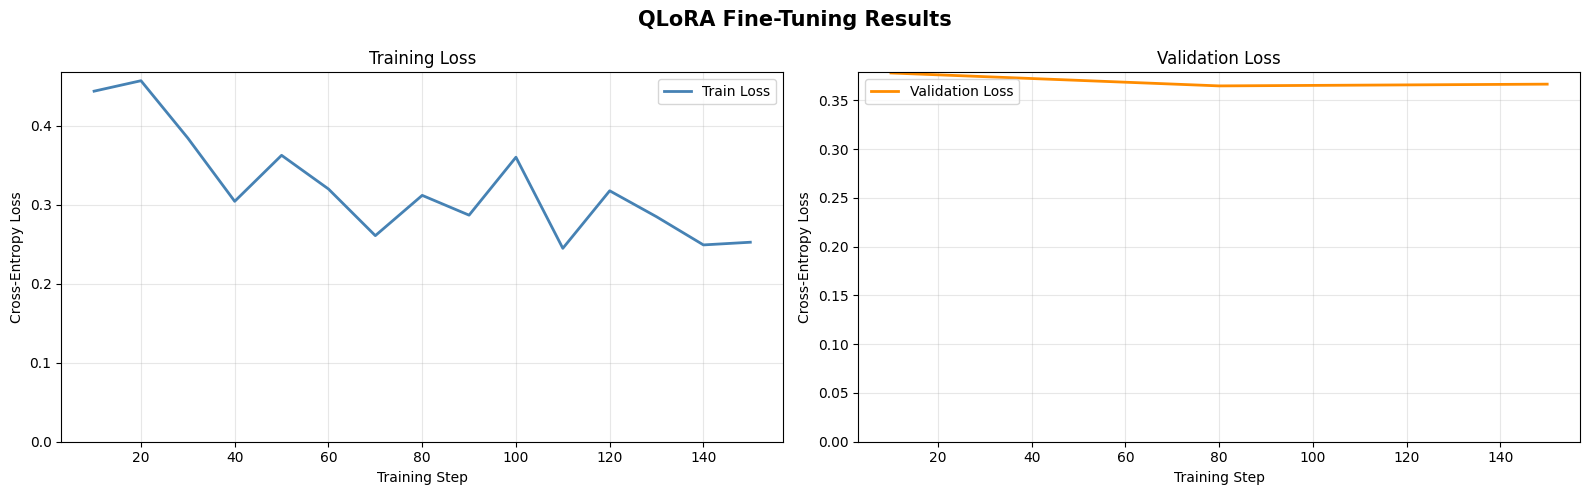

✅ Saved: /kaggle/working/training_curves.png


In [59]:
# ============================================================
# CELL 17: Save Fine-Tuned Model & Plot Training Curves
# ============================================================

# Save model
model.save_pretrained(CFG.FINAL_MODEL_DIR)
processor.save_pretrained(CFG.FINAL_MODEL_DIR)
print(f"✅ Model saved to: {CFG.FINAL_MODEL_DIR}")

# ── Plot training & validation loss curves ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("QLoRA Fine-Tuning Results", fontsize=15, fontweight='bold')

# Training loss
if loss_history["train"]:
    axes[0].plot(loss_history["steps"], loss_history["train"],
                 color='steelblue', linewidth=2, label='Train Loss')
    axes[0].set_xlabel('Training Step')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].set_title('Training Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim(bottom=0)

# Validation loss
if loss_history["eval"]:
    eval_steps_x = np.linspace(
        loss_history["steps"][0] if loss_history["steps"] else 0,
        loss_history["steps"][-1] if loss_history["steps"] else len(loss_history["eval"]),
        len(loss_history["eval"])
    )
    axes[1].plot(eval_steps_x, loss_history["eval"],
                 color='darkorange', linewidth=2, label='Validation Loss')
    axes[1].set_xlabel('Training Step')
    axes[1].set_ylabel('Cross-Entropy Loss')
    axes[1].set_title('Validation Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim(bottom=0)
else:
    axes[1].text(0.5, 0.5, 'Validation Loss\n(will populate during training)',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: /kaggle/working/training_curves.png")

In [60]:
# ============================================================
# CELL 18: Load Fine-Tuned Model for Inference
# ============================================================

print("⬇️  Loading fine-tuned model for inference...")

# Option A: Use the already-trained model in memory
ft_model = model
ft_model.eval()

# Option B (if starting a new session): Load from disk
# ft_model = PeftModel.from_pretrained(
#     Qwen2VLForConditionalGeneration.from_pretrained(
#         CFG.MODEL_ID, quantization_config=bnb_config,
#         device_map="auto", torch_dtype=CFG.COMPUTE_DTYPE,
#         trust_remote_code=True),
#     CFG.FINAL_MODEL_DIR
# )

print("✅ Fine-tuned model ready for inference")

⬇️  Loading fine-tuned model for inference...
✅ Fine-tuned model ready for inference


In [61]:
# ============================================================
# CELL 19: Generate Markdown for Validation Set
# ============================================================

rouge = evaluate.load("rouge")

def evaluate_on_split(model, processor, split_dataset, n_eval=20, label="Validation"):
    """
    Generate markdown predictions for n_eval samples from split_dataset.
    Compute ROUGE scores and return results dict.
    """
    results = []
    n = min(n_eval, len(split_dataset))
    indices = random.sample(range(len(split_dataset)), n)

    print(f"\n🔮 Generating predictions on {n} {label} samples...")
    for i, idx in enumerate(tqdm(indices, desc=f"{label} inference")):
        sample = split_dataset[idx]
        img    = sample["raw_image"]
        gt     = sample["raw_markdown"]

        pred   = generate_markdown(model, processor, img)

        # ROUGE scores
        r = rouge.compute(
            predictions=[pred],
            references=[gt],
            use_stemmer=True
        )

        results.append({
            "idx"       : idx,
            "image"     : img,
            "ground_truth": gt,
            "prediction": pred,
            "rouge1"    : r["rouge1"],
            "rouge2"    : r["rouge2"],
            "rougeL"    : r["rougeL"],
        })

    # Print aggregate metrics
    avg_r1 = np.mean([r["rouge1"] for r in results])
    avg_r2 = np.mean([r["rouge2"] for r in results])
    avg_rL = np.mean([r["rougeL"] for r in results])

    print(f"\n{'='*50}")
    print(f"  {label} ROUGE Scores (n={n}):")
    print(f"  ROUGE-1 : {avg_r1:.4f}")
    print(f"  ROUGE-2 : {avg_r2:.4f}")
    print(f"  ROUGE-L : {avg_rL:.4f}")
    print(f"{'='*50}")

    return results

# Evaluate fine-tuned model on validation set
val_results = evaluate_on_split(
    ft_model, processor, val_dataset,
    n_eval=min(20, len(val_dataset)),
    label="Validation"
)


🔮 Generating predictions on 20 Validation samples...


Validation inference:   0%|          | 0/20 [00:00<?, ?it/s]


  Validation ROUGE Scores (n=20):
  ROUGE-1 : 0.7351
  ROUGE-2 : 0.6165
  ROUGE-L : 0.6935


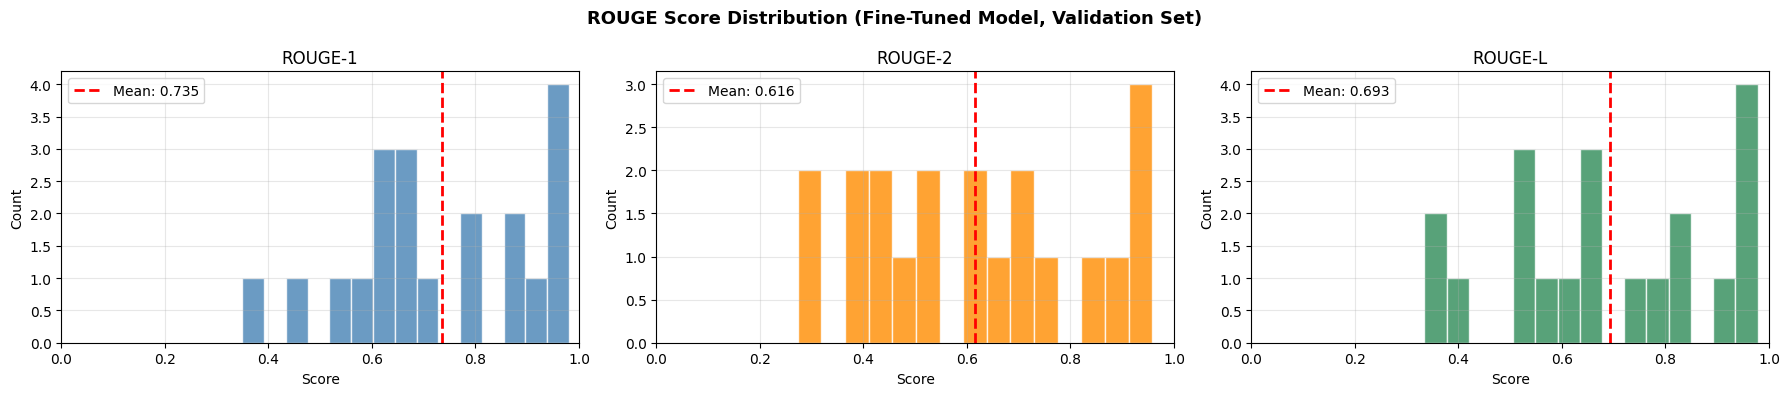

✅ Saved: /kaggle/working/rouge_scores.png


In [62]:
# ============================================================
# CELL 20: ROUGE Score Visualization
# ============================================================

r1_scores = [r["rouge1"] for r in val_results]
r2_scores = [r["rouge2"] for r in val_results]
rL_scores = [r["rougeL"] for r in val_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("ROUGE Score Distribution (Fine-Tuned Model, Validation Set)",
             fontsize=13, fontweight='bold')

for ax, scores, label, color in zip(
    axes,
    [r1_scores, r2_scores, rL_scores],
    ["ROUGE-1", "ROUGE-2", "ROUGE-L"],
    ["steelblue", "darkorange", "seagreen"]
):
    ax.hist(scores, bins=15, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(scores), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {np.mean(scores):.3f}')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('/kaggle/working/rouge_scores.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: /kaggle/working/rouge_scores.png")

In [63]:
# ============================================================
# CELL 21: Test on 3 Training Images
# ============================================================
print("🔬 Running inference on 3 TRAINING images...")

train_test_results = evaluate_on_split(
    ft_model, processor, train_dataset,
    n_eval=3,
    label="Train (sample check)"
)

print("\n📊 Training Sample Predictions:")
for i, r in enumerate(train_test_results, 1):
    print(f"\n{'─'*60}")
    print(f"  TRAINING SAMPLE #{i}")
    print(f"  ROUGE-1: {r['rouge1']:.3f} | ROUGE-2: {r['rouge2']:.3f} | ROUGE-L: {r['rougeL']:.3f}")
    print(f"\n  GROUND TRUTH (first 200 chars):")
    print(f"  {r['ground_truth'][:200]}")
    print(f"\n  PREDICTION (first 200 chars):")
    print(f"  {r['prediction'][:200]}")

🔬 Running inference on 3 TRAINING images...

🔮 Generating predictions on 3 Train (sample check) samples...


Train (sample check) inference:   0%|          | 0/3 [00:00<?, ?it/s]


  Train (sample check) ROUGE Scores (n=3):
  ROUGE-1 : 0.9573
  ROUGE-2 : 0.9303
  ROUGE-L : 0.9573

📊 Training Sample Predictions:

────────────────────────────────────────────────────────────
  TRAINING SAMPLE #1
  ROUGE-1: 0.951 | ROUGE-2: 0.914 | ROUGE-L: 0.951

  GROUND TRUTH (first 200 chars):
  Claus Montonen, Kazuhiko Nishijima, Anca Tureanu, Peter Presnajder and Ram Sriharsha for helpful discussions, as well as an anonymous referee for comments that significantly improved this paper.

This

  PREDICTION (first 200 chars):
  Claas Montonen, Kazuhiko Nishijima, Anca Tureanu, Peter Protsajder and Ram Sriharsha for helpful discussions, as well as an anonymous referee for comments that significantly improved this paper.

This

────────────────────────────────────────────────────────────
  TRAINING SAMPLE #2
  ROUGE-1: 0.947 | ROUGE-2: 0.921 | ROUGE-L: 0.947

  GROUND TRUTH (first 200 chars):
  22. 22.S. A. Larin, F. V. Tkachov, J. A. M. Vermaseren, Phys. Rev. Lett. 66, 862 (1991).

✅ Created unseen document #1: Introduction to Machine Learning
✅ Created unseen document #2: Quantum Computing Overview
✅ Created unseen document #3: Climate Change Report 2024


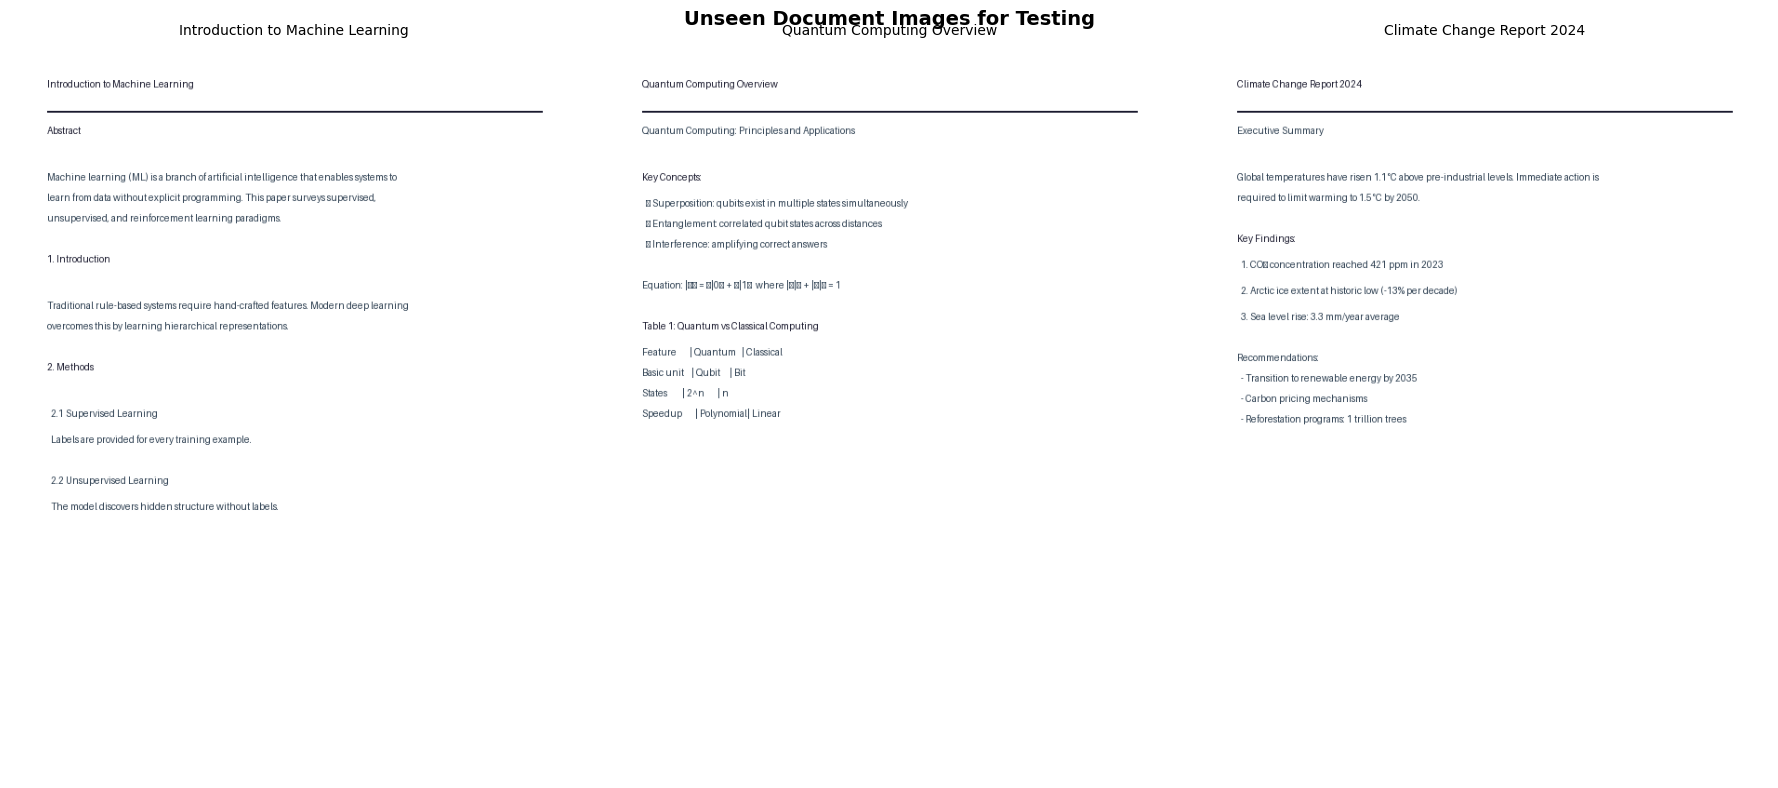

In [64]:
# ============================================================
# CELL 22: Test on 3 Unseen Document Images
# ============================================================
#
# For truly unseen images, we create synthetic document-like
# images programmatically. In a real scenario, you would
# download or photograph actual document pages.
#

from PIL import ImageDraw, ImageFont
import textwrap

UNSEEN_DOCUMENTS = [
    {
        "title"  : "Introduction to Machine Learning",
        "content": (
            "Abstract\n\n"
            "Machine learning (ML) is a branch of artificial intelligence "
            "that enables systems to learn from data without explicit programming. "
            "This paper surveys supervised, unsupervised, and reinforcement learning paradigms.\n\n"
            "1. Introduction\n\n"
            "Traditional rule-based systems require hand-crafted features. "
            "Modern deep learning overcomes this by learning hierarchical representations.\n\n"
            "2. Methods\n\n"
            "  2.1 Supervised Learning\n"
            "  Labels are provided for every training example.\n\n"
            "  2.2 Unsupervised Learning\n"
            "  The model discovers hidden structure without labels."
        )
    },
    {
        "title"  : "Quantum Computing Overview",
        "content": (
            "Quantum Computing: Principles and Applications\n\n"
            "Key Concepts:\n"
            "  • Superposition: qubits exist in multiple states simultaneously\n"
            "  • Entanglement: correlated qubit states across distances\n"
            "  • Interference: amplifying correct answers\n\n"
            "Equation: |ψ⟩ = α|0⟩ + β|1⟩  where |α|² + |β|² = 1\n\n"
            "Table 1: Quantum vs Classical Computing\n"
            "Feature       | Quantum   | Classical\n"
            "Basic unit    | Qubit     | Bit\n"
            "States        | 2^n       | n\n"
            "Speedup       | Polynomial| Linear"
        )
    },
    {
        "title"  : "Climate Change Report 2024",
        "content": (
            "Executive Summary\n\n"
            "Global temperatures have risen 1.1°C above pre-industrial levels. "
            "Immediate action is required to limit warming to 1.5°C by 2050.\n\n"
            "Key Findings:\n"
            "  1. CO₂ concentration reached 421 ppm in 2023\n"
            "  2. Arctic ice extent at historic low (-13% per decade)\n"
            "  3. Sea level rise: 3.3 mm/year average\n\n"
            "Recommendations:\n"
            "  - Transition to renewable energy by 2035\n"
            "  - Carbon pricing mechanisms\n"
            "  - Reforestation programs: 1 trillion trees"
        )
    }
]

def create_document_image(title, content, size=(612, 792)):
    """Create a synthetic document-style PIL Image."""
    img  = Image.new('RGB', size, color='white')
    draw = ImageDraw.Draw(img)

    # Try to use a nice font; fall back to default
    try:
        title_font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 22)
        body_font  = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 13)
    except Exception:
        title_font = ImageFont.load_default()
        body_font  = ImageFont.load_default()

    # Draw title
    draw.text((40, 40), title, fill='#1a1a2e', font=title_font)
    draw.line([(40, 75), (size[0]-40, 75)], fill='#1a1a2e', width=2)

    # Draw content
    y = 90
    for line in content.split('\n'):
        wrapped = textwrap.wrap(line, width=85) if line.strip() else [""]
        for wl in wrapped:
            if y > size[1] - 40:
                break
            color = '#2c3e50' if not line.startswith(('1.','2.','3.','Key','Abstract','Table')) else '#1a1a2e'
            font  = title_font if line.strip().startswith(("Abstract","1.","2.","Key","Executive","Table","Quantum")) else body_font
            draw.text((40, y), wl, fill=color, font=font)
            y += 22 if font == body_font else 28

    return img

# Create & save unseen document images
unseen_images = []
for i, doc in enumerate(UNSEEN_DOCUMENTS):
    img = create_document_image(doc["title"], doc["content"])
    img.save(f'/kaggle/working/unseen_doc_{i+1}.png')
    unseen_images.append(img)
    print(f"✅ Created unseen document #{i+1}: {doc['title']}")

# Preview unseen images
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle("Unseen Document Images for Testing", fontsize=14, fontweight='bold')
for ax, img, doc in zip(axes, unseen_images, UNSEEN_DOCUMENTS):
    ax.imshow(img)
    ax.set_title(doc["title"], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/unseen_documents.png', dpi=120, bbox_inches='tight')
plt.show()

In [65]:
# ============================================================
# CELL 23: Generate Markdown for Unseen Documents
# ============================================================
print("🔮 Generating Markdown for 3 UNSEEN documents...\n")

unseen_results = []
for i, (img, doc) in enumerate(zip(unseen_images, UNSEEN_DOCUMENTS), 1):
    proc_img = preprocess_image(img, CFG.IMAGE_SIZE)
    print(f"\n{'─'*60}")
    print(f"  UNSEEN DOCUMENT #{i}: {doc['title']}")
    print(f"{'─'*60}")

    pred = generate_markdown(ft_model, processor, proc_img)

    print(f"  PREDICTION:")
    print(f"  {pred[:400]}")

    unseen_results.append({
        "idx"       : i,
        "title"     : doc["title"],
        "image"     : proc_img,
        "prediction": pred,
        "content"   : doc["content"]
    })

🔮 Generating Markdown for 3 UNSEEN documents...


────────────────────────────────────────────────────────────
  UNSEEN DOCUMENT #1: Introduction to Machine Learning
────────────────────────────────────────────────────────────
  PREDICTION:
  # Introduction to Machine Learning

## Machine learning (ML) is a branch of artificial intelligence that enables systems to learn from data without explicit programming. This paper surveys supervised, unsupervised, and reinforcement learning paradigms

## 1 Introduction

Traditional rule-based systems require hand-crafted features. Modern deep learning overcomes this by learning hierarchical repre

────────────────────────────────────────────────────────────
  UNSEEN DOCUMENT #2: Quantum Computing Overview
────────────────────────────────────────────────────────────
  PREDICTION:
  # Quantum Computing Overview

## Quantum Computing: Principles and Applications

### Key Concepts

* **Superposition:** qubits exist in multiple states simultaneously
*

✅ Saved: /kaggle/working/val_comparison.png


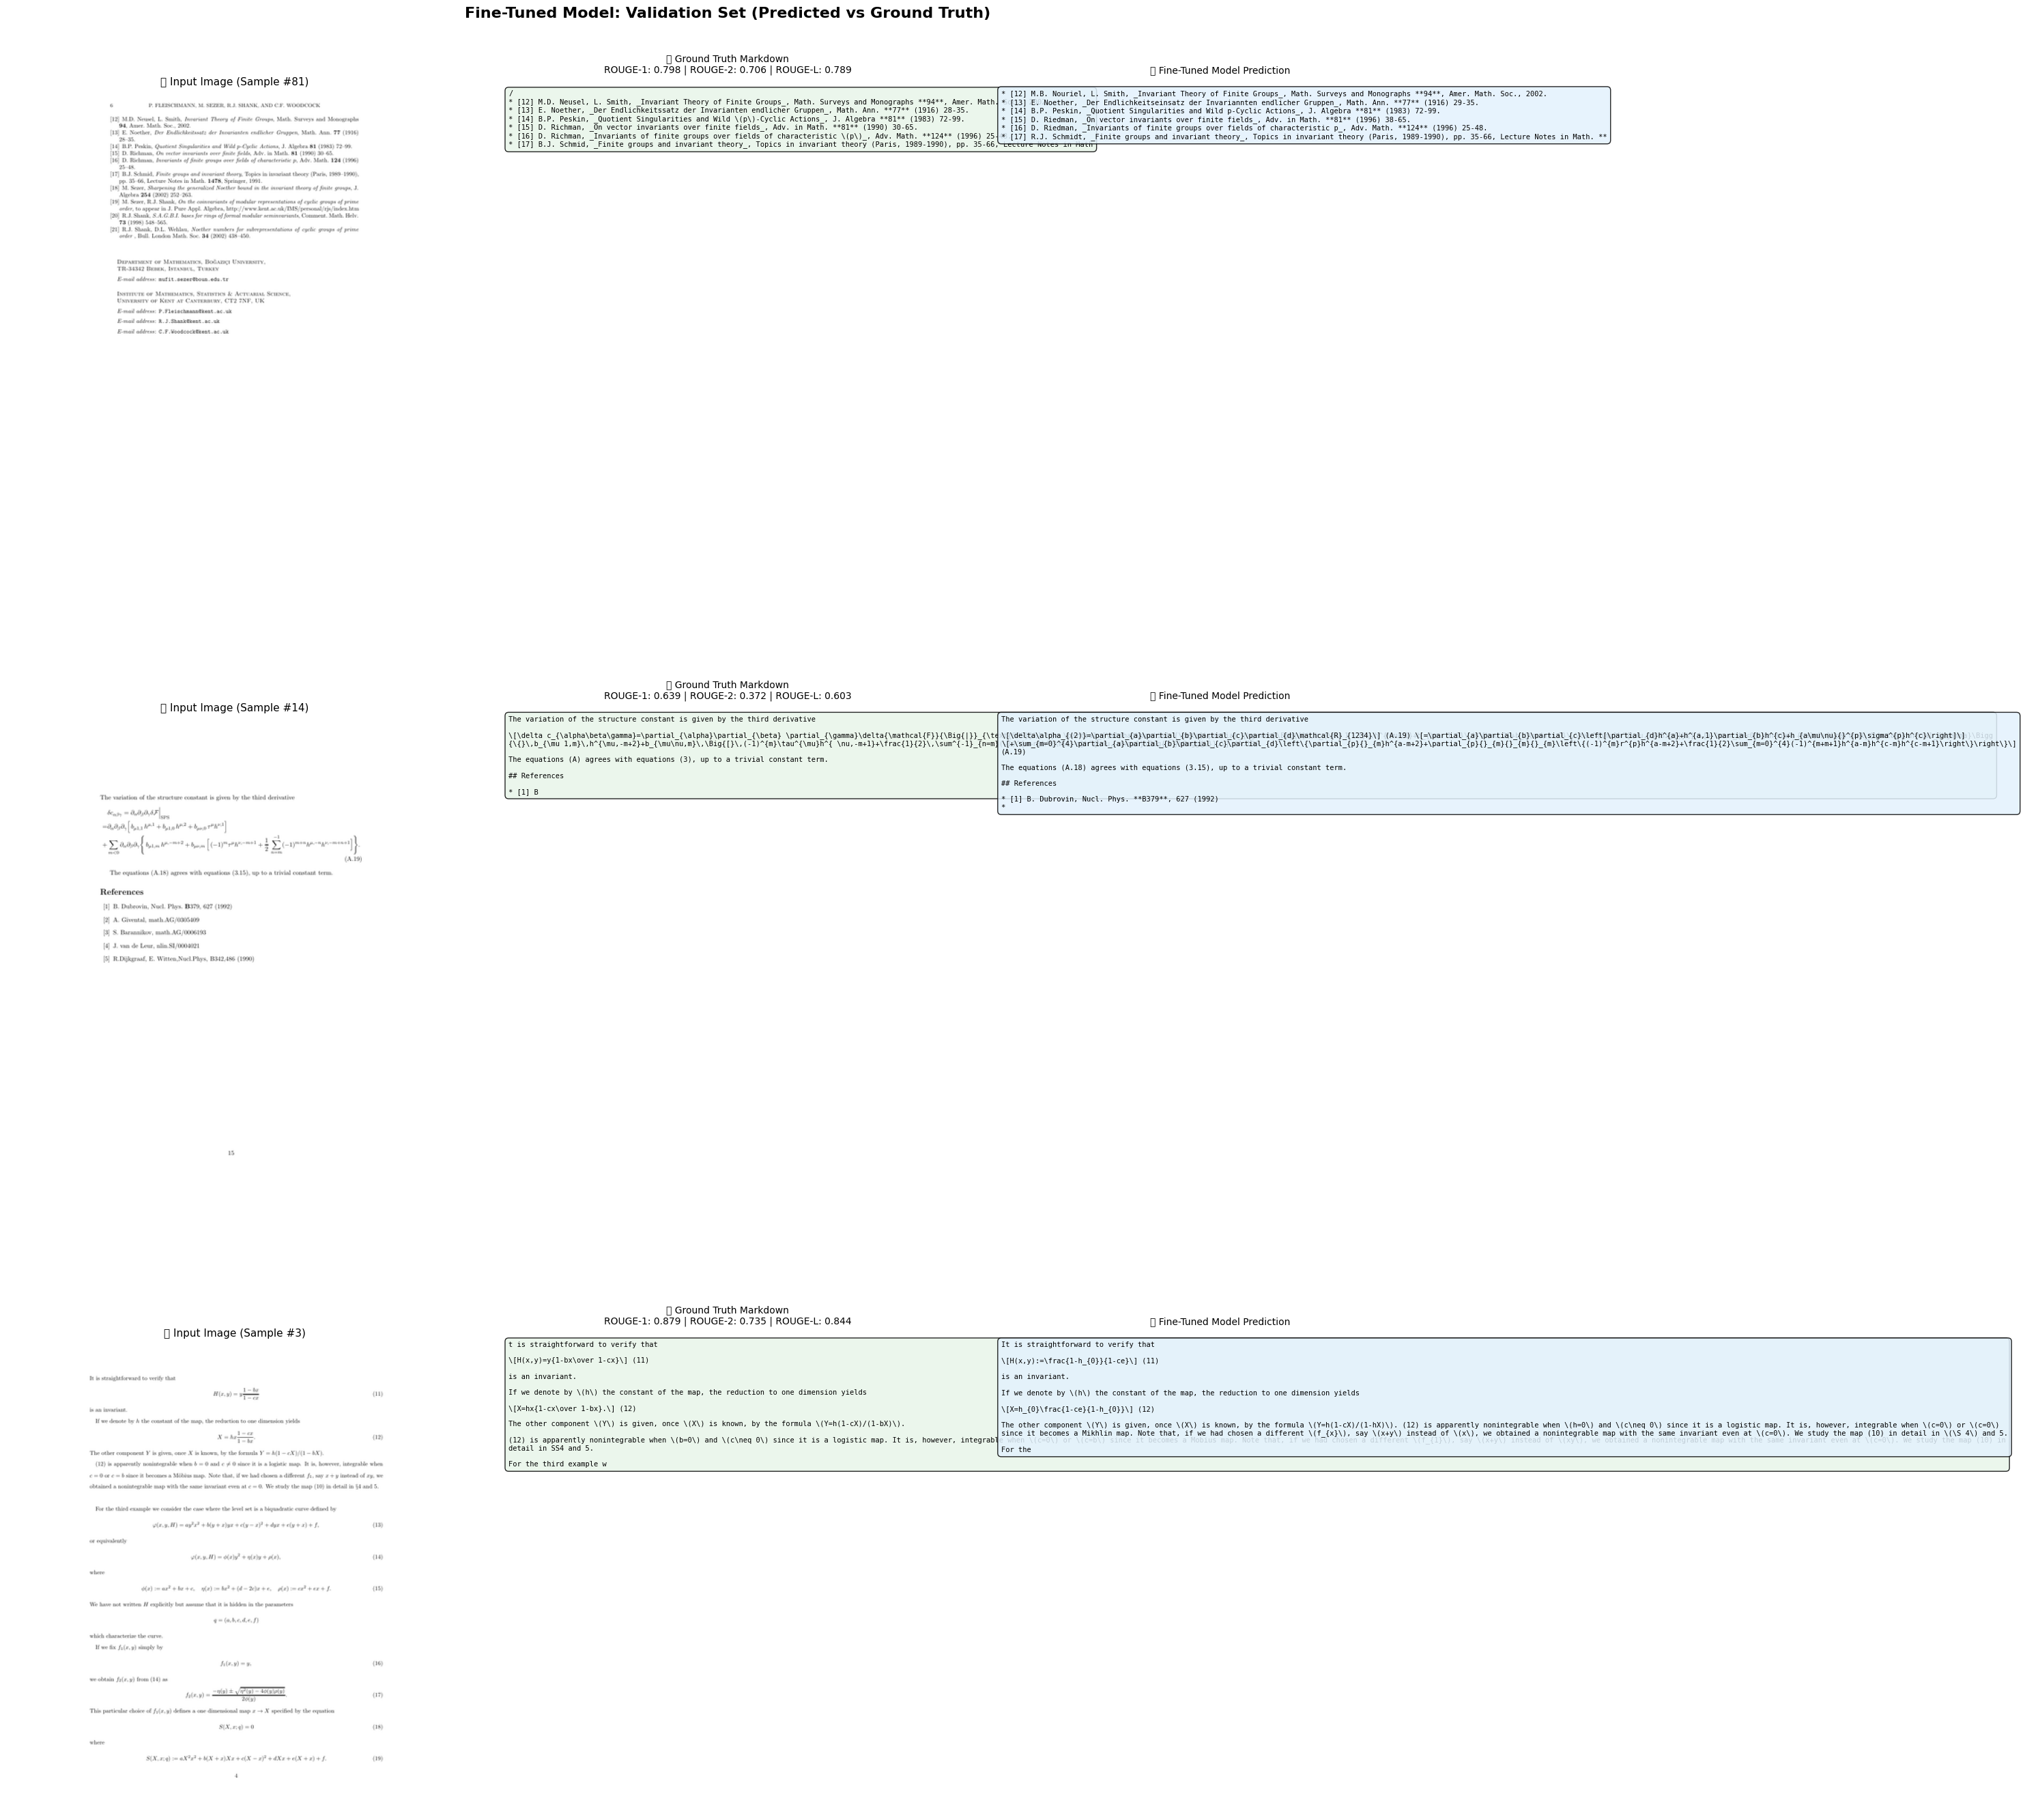

In [66]:
# ============================================================
# CELL 24: Full Visualization – Validation Samples
# ============================================================

def visualize_comparison(results, title="Predicted vs Ground Truth",
                          n=3, save_path=None):
    """
    For each result: show image | ground truth markdown | predicted markdown
    """
    n = min(n, len(results))
    fig = plt.figure(figsize=(22, 9 * n))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)

    for row, r in enumerate(results[:n]):
        gs = gridspec.GridSpec(n, 3, figure=fig,
                               left=0.02, right=0.98,
                               top=0.97, bottom=0.03,
                               wspace=0.08, hspace=0.3)

        # ── Column 1: Document Image ───────────────────────
        ax_img = fig.add_subplot(gs[row, 0])
        ax_img.imshow(r["image"], cmap='gray' if r["image"].mode=='L' else None)
        ax_img.set_title(f"📄 Input Image (Sample #{r.get('idx', row+1)})",
                         fontsize=11, pad=8)
        ax_img.axis('off')

        # ── Column 2: Ground Truth ─────────────────────────
        ax_gt = fig.add_subplot(gs[row, 1])
        ax_gt.axis('off')
        gt_preview = r.get("ground_truth", r.get("content", ""))[:700]
        ax_gt.text(
            0.02, 0.98, gt_preview,
            transform=ax_gt.transAxes,
            fontsize=7.5, va='top', ha='left',
            family='monospace', wrap=True,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#e8f5e9', alpha=0.85)
        )
        scores = ""
        if "rouge1" in r:
            scores = (f"\nROUGE-1: {r['rouge1']:.3f} | "
                      f"ROUGE-2: {r['rouge2']:.3f} | "
                      f"ROUGE-L: {r['rougeL']:.3f}")
        ax_gt.set_title(f"✅ Ground Truth Markdown{scores}", fontsize=10, pad=8)

        # ── Column 3: Model Prediction ─────────────────────
        ax_pr = fig.add_subplot(gs[row, 2])
        ax_pr.axis('off')
        pred_preview = r["prediction"][:700]
        ax_pr.text(
            0.02, 0.98, pred_preview,
            transform=ax_pr.transAxes,
            fontsize=7.5, va='top', ha='left',
            family='monospace', wrap=True,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#e3f2fd', alpha=0.85)
        )
        ax_pr.set_title("🤖 Fine-Tuned Model Prediction", fontsize=10, pad=8)

    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"✅ Saved: {save_path}")
    plt.show()


# Visualize validation results
visualize_comparison(
    val_results[:3],
    title="Fine-Tuned Model: Validation Set (Predicted vs Ground Truth)",
    n=3,
    save_path='/kaggle/working/val_comparison.png'
)

✅ Saved: /kaggle/working/unseen_comparison.png


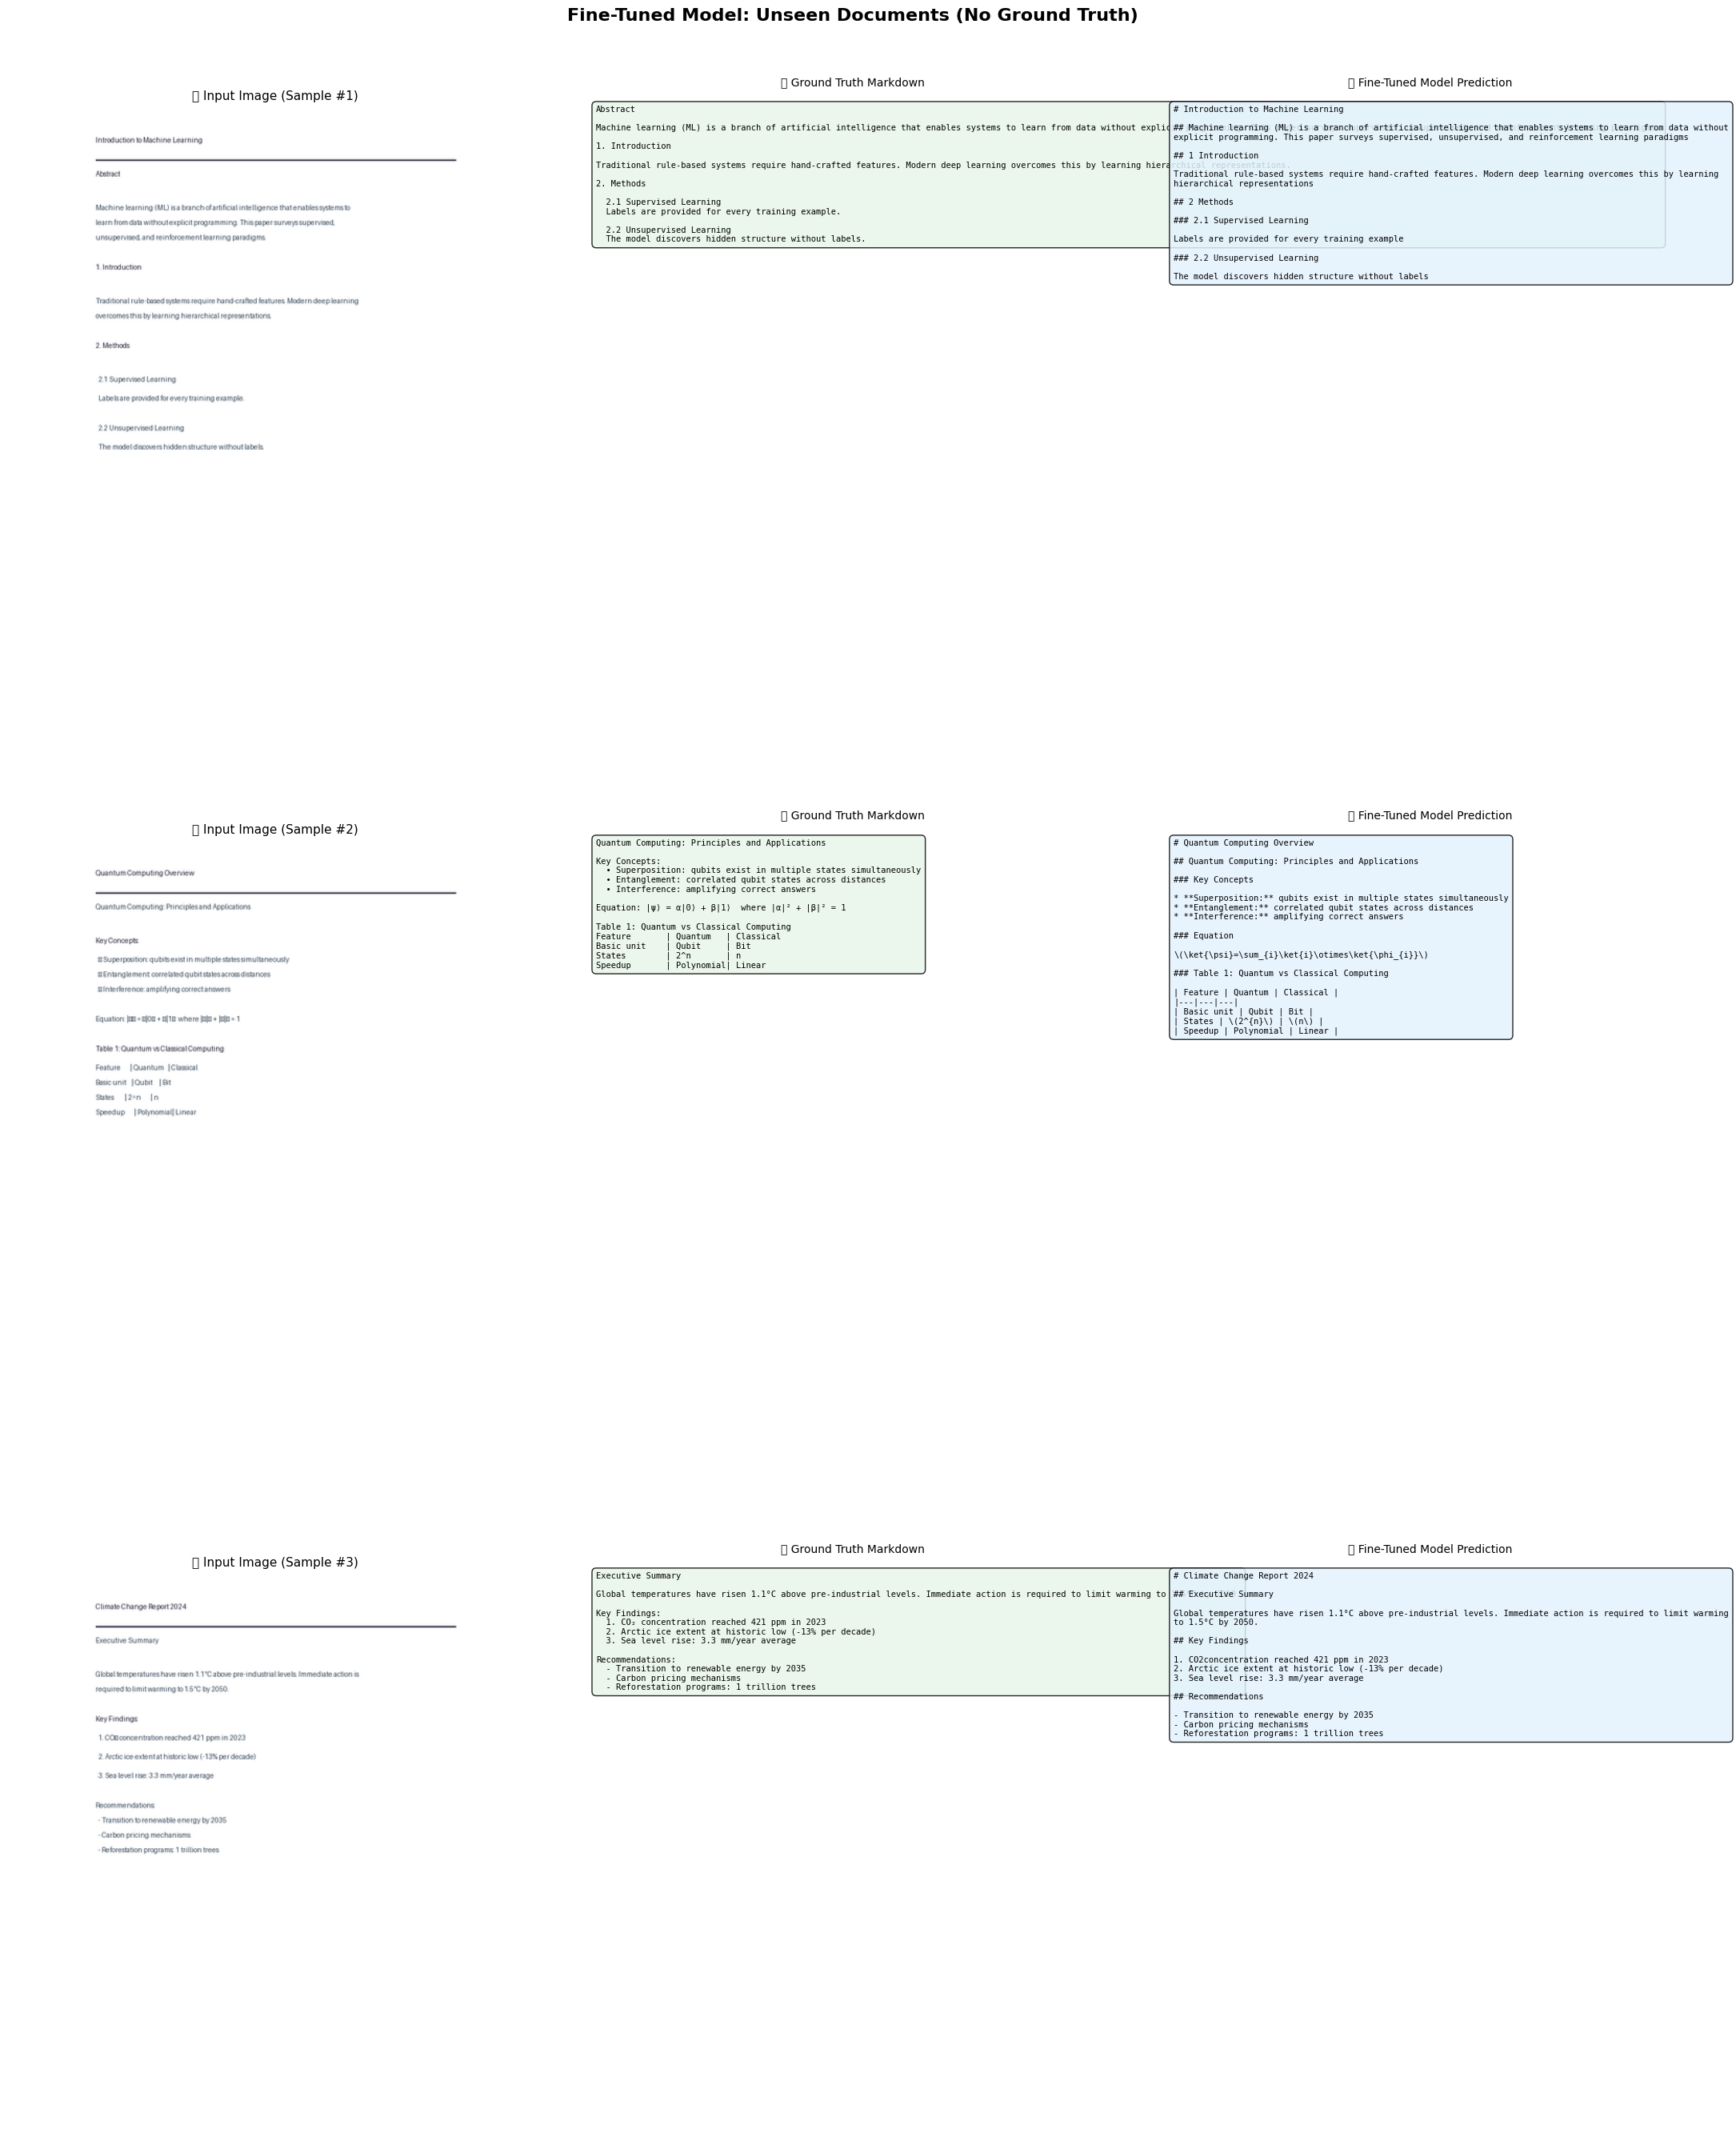

In [67]:
# ============================================================
# CELL 25: Visualize Unseen Document Results
# ============================================================

visualize_comparison(
    unseen_results,
    title="Fine-Tuned Model: Unseen Documents (No Ground Truth)",
    n=3,
    save_path='/kaggle/working/unseen_comparison.png'
)

🏆 BONUS: Zero-Shot vs Fine-Tuned Comparison


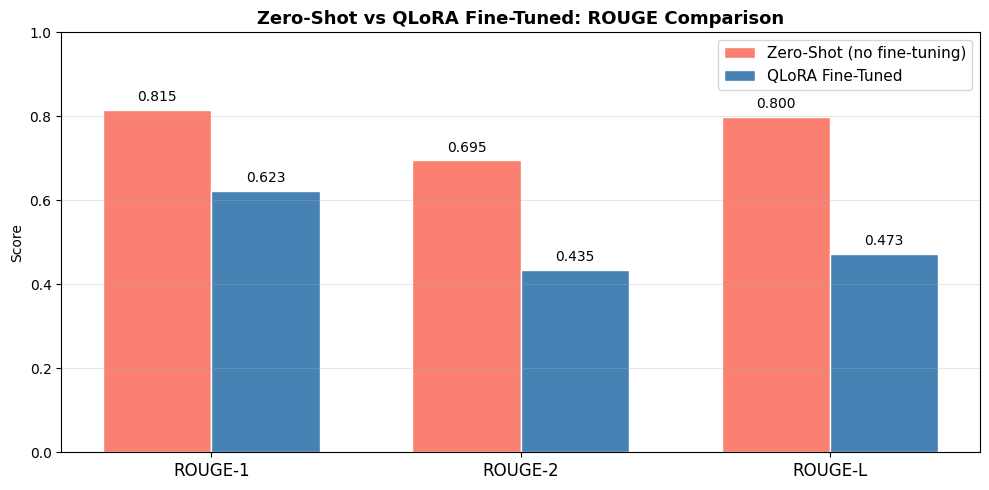


📊 Improvement from QLoRA Fine-Tuning:
   ROUGE-1 : 0.815 → 0.623  (+-0.192)
   ROUGE-2 : 0.695 → 0.435  (+-0.260)
   ROUGE-L : 0.800 → 0.473  (+-0.326)


In [68]:
# ============================================================
# CELL 26: BONUS – Zero-Shot vs Fine-Tuned Comparison
# ============================================================
print("🏆 BONUS: Zero-Shot vs Fine-Tuned Comparison")

# Use same val samples from zero_shot_pred earlier
compare_img = val_dataset[0]["raw_image"]
compare_gt  = val_dataset[0]["raw_markdown"]

# We already have zero_shot_pred from Cell 12
ft_pred     = generate_markdown(ft_model, processor, compare_img)

# Score both
zs_rouge = rouge.compute(predictions=[zero_shot_pred], references=[compare_gt], use_stemmer=True)
ft_rouge = rouge.compute(predictions=[ft_pred],        references=[compare_gt], use_stemmer=True)

# Bar chart comparison
metrics     = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
zs_scores   = [zs_rouge["rouge1"], zs_rouge["rouge2"], zs_rouge["rougeL"]]
ft_scores   = [ft_rouge["rouge1"], ft_rouge["rouge2"], ft_rouge["rougeL"]]

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, zs_scores, w, label='Zero-Shot (no fine-tuning)',
               color='salmon', edgecolor='white')
bars2 = ax.bar(x + w/2, ft_scores, w, label='QLoRA Fine-Tuned',
               color='steelblue', edgecolor='white')

ax.set_ylabel('Score')
ax.set_title('Zero-Shot vs QLoRA Fine-Tuned: ROUGE Comparison',
             fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/zero_shot_vs_finetuned.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n📊 Improvement from QLoRA Fine-Tuning:")
print(f"   ROUGE-1 : {zs_scores[0]:.3f} → {ft_scores[0]:.3f}  (+{ft_scores[0]-zs_scores[0]:+.3f})")
print(f"   ROUGE-2 : {zs_scores[1]:.3f} → {ft_scores[1]:.3f}  (+{ft_scores[1]-zs_scores[1]:+.3f})")
print(f"   ROUGE-L : {zs_scores[2]:.3f} → {ft_scores[2]:.3f}  (+{ft_scores[2]-zs_scores[2]:+.3f})")

In [69]:
# ============================================================
# CELL 27: Gradio App
# ============================================================
import gradio as gr

# ── Helper: render markdown side-by-side with image ──────────
def document_to_markdown_app(image_input, prompt_style="Standard"):
    """
    Gradio inference function.
    image_input : numpy array from Gradio
    prompt_style: one of [Standard, Detailed, Minimal]
    """
    if image_input is None:
        return "⚠️ Please upload a document image."

    # Prompt styles (bonus: compare prompt styles)
    prompts = {
        "Standard" : CFG.INSTRUCTION,
        "Detailed" : (
            "You are a precise document OCR system. "
            "Analyze the uploaded document page and produce complete Markdown. "
            "Include: # for headings, ** for bold, * for italic, "
            "- for bullets, 1. for numbered lists, | for tables, "
            "``` for code blocks, $$ for equations. "
            "Reproduce all text verbatim."
        ),
        "Minimal"  : "Convert this document image to Markdown.",
    }
    instruction = prompts.get(prompt_style, CFG.INSTRUCTION)

    # Convert numpy → PIL
    pil_img = Image.fromarray(image_input.astype('uint8'))
    pil_img = preprocess_image(pil_img, CFG.IMAGE_SIZE)

    try:
        result = generate_markdown(ft_model, processor, pil_img,
                                   instruction=instruction,
                                   max_new_tokens=CFG.MAX_NEW_TOKENS)
    except Exception as e:
        result = f"❌ Error during generation: {str(e)}"

    return result


# ── Build Gradio Interface ───────────────────────────────────
with gr.Blocks(
    title="Document → Markdown | Qwen2-VL QLoRA",
    theme=gr.themes.Soft()
) as demo:

    gr.Markdown("""
    # 📄 Document → Markdown Generator
    ### Powered by Qwen2-VL-2B-Instruct fine-tuned with QLoRA

    Upload a document image (scanned paper, research article, textbook page) and the model
    will generate structured Markdown preserving headings, tables, lists, and equations.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(
                label="📤 Upload Document Image",
                type="numpy",
                height=500,
            )
            prompt_style = gr.Radio(
                choices=["Standard", "Detailed", "Minimal"],
                value="Standard",
                label="🎨 Prompt Style",
                info="Affects how the model is instructed to generate Markdown"
            )
            generate_btn = gr.Button(
                "🚀 Generate Markdown",
                variant="primary",
                size="lg"
            )

        with gr.Column(scale=1):
            markdown_output = gr.Textbox(
                label="📝 Generated Markdown",
                lines=25,
                max_lines=50,
                placeholder="Generated Markdown will appear here...",
            )
            rendered_output = gr.Markdown(
                label="👁️ Rendered Preview",
                value="Rendered Markdown will appear here..."
            )

    generate_btn.click(
        fn=document_to_markdown_app,
        inputs=[image_input, prompt_style],
        outputs=[markdown_output]
    )

    markdown_output.change(
        fn=lambda x: x,
        inputs=[markdown_output],
        outputs=[rendered_output]
    )

    gr.Markdown("""
    ---
    **Model:** Qwen2-VL-2B-Instruct | **Fine-Tuning:** QLoRA (4-bit, LoRA rank 16) |
    **Dataset:** Nougat Training Dataset
    """)

print("🚀 Launching Gradio App...")
demo.launch(
    share=True,       # Creates a public link (works on Kaggle)
    debug=False,
    show_error=True,
)

🚀 Launching Gradio App...
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://7bde547b0328d4738c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [70]:
# ============================================================
# CELL 28: Print Final Summary
# ============================================================

print("=" * 65)
print("  FINAL EXPERIMENT SUMMARY")
print("=" * 65)

print(f"""
📌 MODEL CONFIGURATION
   Base model          : {CFG.MODEL_ID}
   Quantization        : 4-bit NF4 (QLoRA)
   LoRA rank (r)       : {CFG.LORA_R}
   LoRA alpha          : {CFG.LORA_ALPHA}
   Target modules      : {', '.join(CFG.LORA_TARGETS)}
   Trainable params    : {trainable_params:,} ({100*trainable_params/total_params:.2f}% of total)

📌 TRAINING CONFIGURATION
   Epochs              : {CFG.NUM_EPOCHS}
   Batch size          : {CFG.BATCH_SIZE}
   Gradient accum.     : {CFG.GRAD_ACCUM}
   Effective batch     : {CFG.BATCH_SIZE * CFG.GRAD_ACCUM}
   Learning rate       : {CFG.LEARNING_RATE}
   LR scheduler        : {CFG.LR_SCHEDULER}
   Image size          : {CFG.IMAGE_SIZE}px
   Max sequence length : {CFG.MAX_SEQ_LEN}

📌 DATASET
   Source              : {CFG.DATASET_NAME}
   Total used          : {n_use}
   Training samples    : {len(train_dataset)}
   Validation samples  : {len(val_dataset)}

📌 RESULTS
   Final train loss    : {train_result.training_loss:.4f}
   Avg Val ROUGE-1     : {np.mean([r['rouge1'] for r in val_results]):.4f}
   Avg Val ROUGE-2     : {np.mean([r['rouge2'] for r in val_results]):.4f}
   Avg Val ROUGE-L     : {np.mean([r['rougeL'] for r in val_results]):.4f}

📌 ZERO-SHOT vs FINE-TUNED (single sample)
   ROUGE-1 : {zs_scores[0]:.3f} (zero-shot) → {ft_scores[0]:.3f} (fine-tuned)  Δ = {ft_scores[0]-zs_scores[0]:+.3f}
   ROUGE-2 : {zs_scores[1]:.3f} (zero-shot) → {ft_scores[1]:.3f} (fine-tuned)  Δ = {ft_scores[1]-zs_scores[1]:+.3f}
   ROUGE-L : {zs_scores[2]:.3f} (zero-shot) → {ft_scores[2]:.3f} (fine-tuned)  Δ = {ft_scores[2]-zs_scores[2]:+.3f}

📌 SAVED FILES
   Fine-tuned model    : {CFG.FINAL_MODEL_DIR}
   Training curves     : /kaggle/working/training_curves.png
   ROUGE scores        : /kaggle/working/rouge_scores.png
   Val comparison      : /kaggle/working/val_comparison.png
   Unseen comparison   : /kaggle/working/unseen_comparison.png
   ZS vs FT chart      : /kaggle/working/zero_shot_vs_finetuned.png
""")
print("=" * 65)
print("✅ All tasks completed successfully!")
print("=" * 65)

  FINAL EXPERIMENT SUMMARY

📌 MODEL CONFIGURATION
   Base model          : Qwen/Qwen2-VL-2B-Instruct
   Quantization        : 4-bit NF4 (QLoRA)
   LoRA rank (r)       : 16
   LoRA alpha          : 32
   Target modules      : q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj
   Trainable params    : 18,464,768 (1.49% of total)

📌 TRAINING CONFIGURATION
   Epochs              : 3
   Batch size          : 1
   Gradient accum.     : 8
   Effective batch     : 8
   Learning rate       : 0.0001
   LR scheduler        : cosine
   Image size          : 512px
   Max sequence length : 1024

📌 DATASET
   Source              : zphilip/nougat-training-dataset-example
   Total used          : 500
   Training samples    : 400
   Validation samples  : 100

📌 RESULTS
   Final train loss    : 0.3225
   Avg Val ROUGE-1     : 0.7351
   Avg Val ROUGE-2     : 0.6165
   Avg Val ROUGE-L     : 0.6935

📌 ZERO-SHOT vs FINE-TUNED (single sample)
   ROUGE-1 : 0.815 (zero-shot) → 0.623 (fine-tuned)  Δ =